# 식수 인원 및 기상 데이터 상관관계 EDA (dining_EDA.ipynb)

이 노트북에서는 `weather.csv`로 통합된 외부 기상 데이터와 기존 식수 인원 데이터 간의 연관성을 상세하게 분석합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import korean_font
korean_font.set_korean_font()

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


## 1. 데이터 로드 및 병합

In [2]:
train = pd.read_csv('data/train.csv')
weather = pd.read_csv('data/weather.csv')

train['일자'] = pd.to_datetime(train['일자'])
weather['일시'] = pd.to_datetime(weather['일시'])

df = pd.merge(train, weather, left_on='일자', right_on='일시', how='left')
print(f"Merged Data Shape: {df.shape}")
display(df.head())

Merged Data Shape: (1208, 23)


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,...,지점명,일시,기온,강수량,풍속,습도,일사량,적설,전운량,지면온도
0,2016-02-01,월,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",...,진주,2016-02-01,-0.6,NaN,1.3,43.9,9.56,NaN,NaN,2.3
1,2016-02-02,화,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",...,진주,2016-02-02,-2.3,NaN,0.8,47.5,10.40,NaN,NaN,1.2
2,2016-02-03,수,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",...,진주,2016-02-03,-1.7,NaN,0.6,57.1,10.32,NaN,NaN,1.3
3,2016-02-04,목,2601,104,220,355,0.0,"모닝롤/토마토샌드 우유/두유/주스 계란후라이 닭죽/쌀밥 (쌀,닭:국내산) 근대국...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 쇠고기무국 주꾸미볶음 부추전 시금치나물 ...","미니김밥*겨자장 (쌀,현미흑미:국내산) 우동 멕시칸샐러드 군고구마 무피클 포...",...,진주,2016-02-04,-0.2,NaN,0.7,53.4,6.60,NaN,NaN,1.0
4,2016-02-05,금,2601,278,181,34,0.0,모닝롤/와플 우유/두유/주스 계란후라이 쇠고기죽/쌀밥 (쌀:국내산) 재첩국 방...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 떡국 돈육씨앗강정 (돼지고기:국내산) 우엉잡채...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 차돌박이찌개 (쇠고기:호주산) 닭갈비 (닭고기:...",...,진주,2016-02-05,1.3,NaN,1.0,44.4,10.32,NaN,NaN,2.4


## 2. 기상 데이터 결측치 및 분포 확인

Null values in weather features:
기온         1
강수량      822
풍속         1
습도         1
일사량        2
적설      1208
전운량      616
지면온도       5
dtype: int64


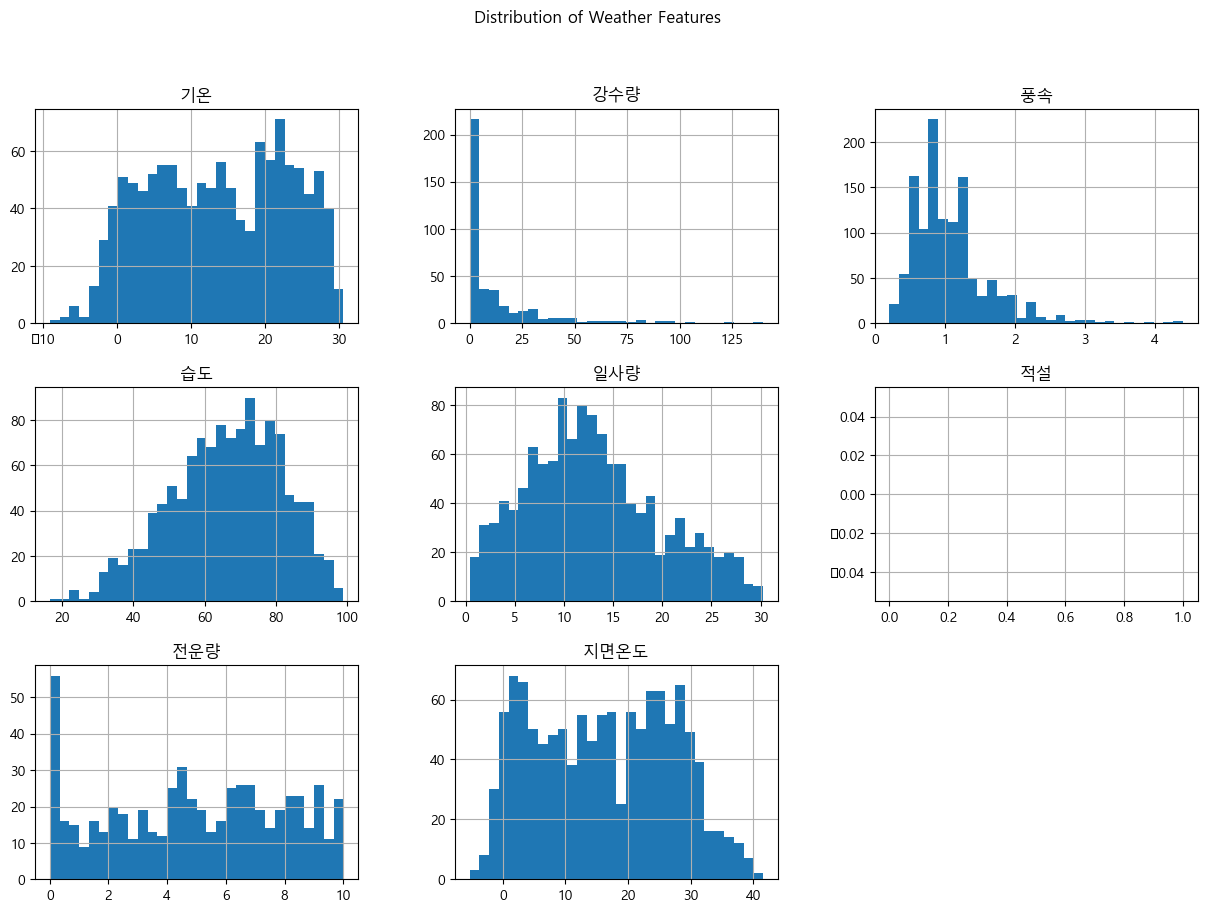

In [3]:
weather_cols = ['기온', '강수량', '풍속', '습도', '일사량', '적설', '전운량', '지면온도']
print("Null values in weather features:")
print(df[weather_cols].isnull().sum())

df[weather_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Distribution of Weather Features')
plt.show()

## 3. 식수 인원과의 상관관계 분석

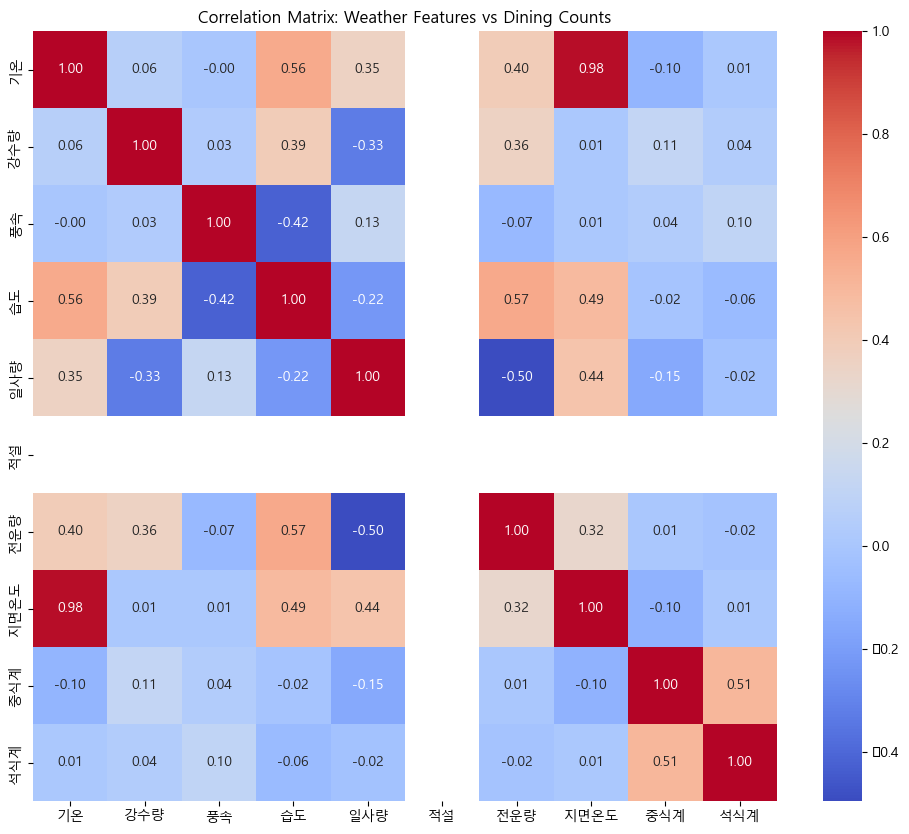

In [4]:
corr_cols = weather_cols + ['중식계', '석식계']
plt.figure(figsize=(12, 10))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Weather Features vs Dining Counts')
plt.show()

### 3.1 기온과 식수 인원 분석
기온이 극단적으로 높거나 낮을 때 외부 외출을 꺼려 식수 인원이 증가하는지 확인합니다.

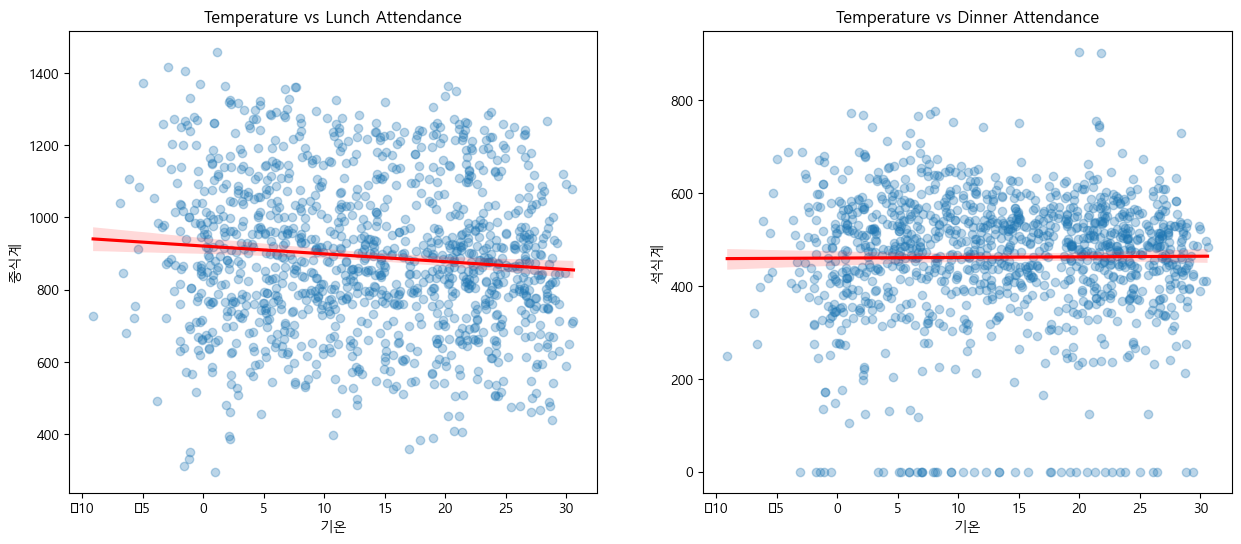

In [5]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='기온', y='중식계', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Temperature vs Lunch Attendance')

plt.subplot(1, 2, 2)
sns.regplot(data=df, x='기온', y='석식계', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Temperature vs Dinner Attendance')
plt.show()

### 3.2 강수 여부에 따른 식수 인원 차이
비가 오는 날은 단체 급식 이용률이 유의미하게 달라지는지 분석합니다.

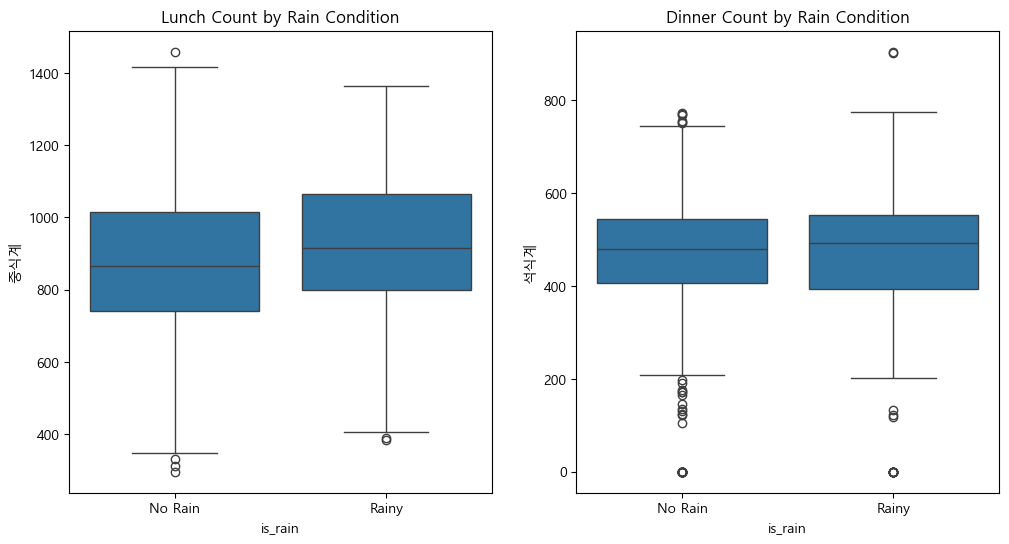

Mean counts by rain condition:
                중식계         석식계
is_rain                        
No Rain  879.192436  461.263626
Rainy    924.029126  463.161812


In [6]:
df['is_rain'] = df['강수량'].apply(lambda x: 'Rainy' if x > 0 else 'No Rain')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='is_rain', y='중식계')
plt.title('Lunch Count by Rain Condition')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='is_rain', y='석식계')
plt.title('Dinner Count by Rain Condition')
plt.show()

print("Mean counts by rain condition:")
print(df.groupby('is_rain')[['중식계', '석식계']].mean())

### 3.3 습도와 식수 인원
불쾌지수와 연관이 있는 습도가 식수 인원에 미치는 영향을 시각화합니다.

<Figure size 1000x600 with 0 Axes>

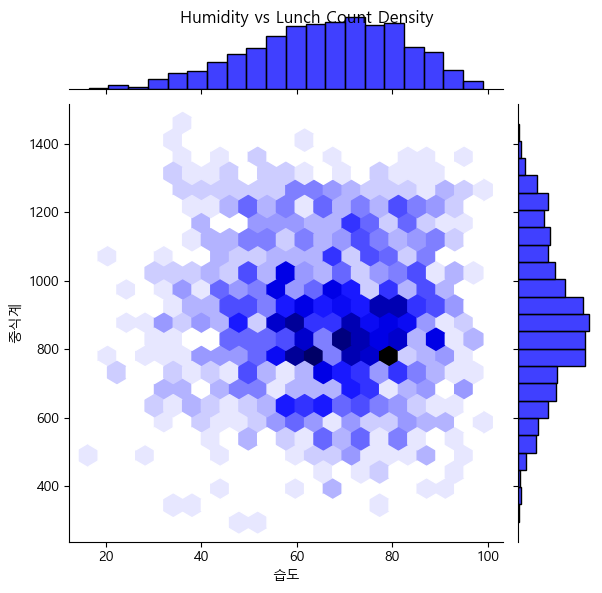

In [7]:
plt.figure(figsize=(10, 6))
sns.jointplot(data=df, x='습도', y='중식계', kind='hex', color='blue')
plt.suptitle('Humidity vs Lunch Count Density')
plt.show()

## 4. 요일 및 월별 기상 보정 트렌드
특정 계절이나 요일에 기상이 복합적으로 작용하는 패턴을 탐색합니다.

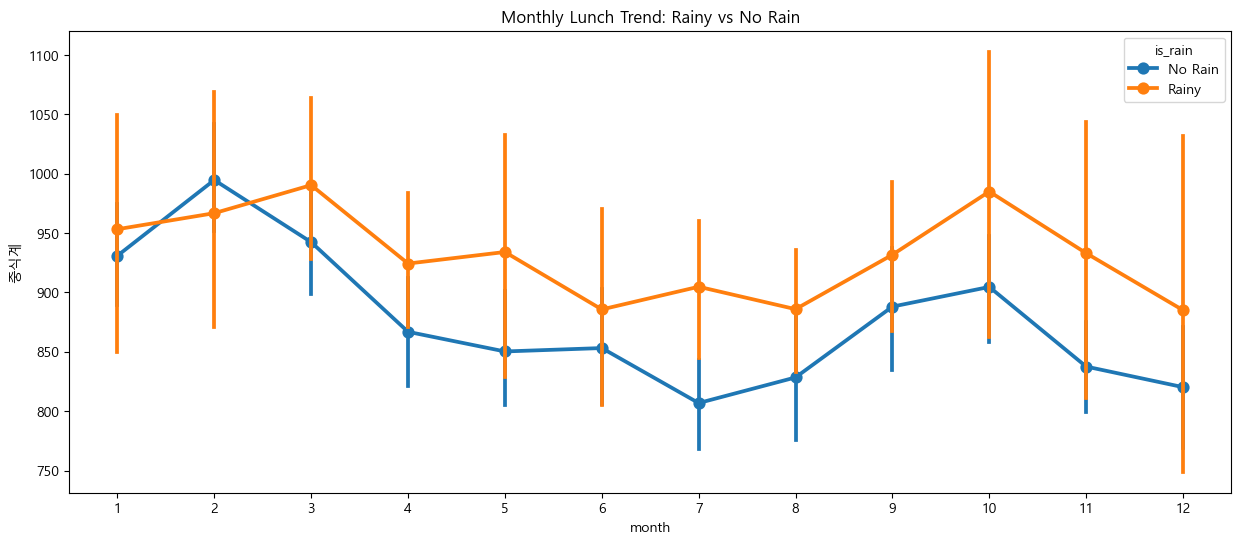

In [8]:
df['month'] = df['일자'].dt.month
plt.figure(figsize=(15, 6))
sns.pointplot(data=df, x='month', y='중식계', hue='is_rain')
plt.title('Monthly Lunch Trend: Rainy vs No Rain')
plt.show()